# AOD EDA: MODIS vs Himawari (L3 Envisoft)

Exploratory Data Analysis comparing Aerosol Optical Depth (AOD) measurements from:
- **MODIS MCD19A2** — `Optical_Depth_047` and `Optical_Depth_055`
- **Himawari L3 Envisoft** — `AOT_Merged` (primary product)

Goals:
1. Load and clean both datasets per station
2. Merge on overlapping timestamps
3. Correlation analysis (scatter plots, R², RMSE, bias)
4. Time-series comparison per station
5. Aggregate statistics across all stations

## 0 · Imports & Configuration

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# ── Paths ──────────────────────────────────────────────────────────────────
MODIS_DIR = Path('/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod')
HIMA_DIR  = Path('/home/slow_data/Air_Quality/AOD/station_aod/L3_envisoft_stations')

# ── MODIS bands to analyse
MODIS_BANDS = ['Optical_Depth_047', 'Optical_Depth_055']

print('MODIS dir exists :', MODIS_DIR.exists())
print('Himawari dir exists:', HIMA_DIR.exists())

MODIS dir exists : True
Himawari dir exists: True


## 1 · Discover Station Files

In [2]:
def extract_station_id(path: Path) -> str:
    """Pull the numeric station ID from either filename convention."""
    return re.sub(r'^MODIS_AQI_', '', path.stem)

modis_files = {extract_station_id(f): f for f in MODIS_DIR.glob('MODIS_AQI_*.csv')}
hima_files  = {f.stem: f              for f in HIMA_DIR.glob('*.csv')}

common_ids = sorted(set(modis_files) & set(hima_files))

print(f'MODIS stations   : {len(modis_files)}')
print(f'Himawari stations: {len(hima_files)}')
print(f'Common stations  : {len(common_ids)}')
print('\nFirst 10 common IDs:')
for sid in common_ids[:10]:
    print(' ', sid)

MODIS stations   : 13
Himawari stations: 13
Common stations  : 13

First 10 common IDs:
  28505268571336961948594948504
  28560877461938780203765592307
  29195707587706641566224751462
  29213751141295132066317063859
  31387251434693138681789561386
  31388839920718814259329251882
  31388851800421997746903202346
  31388883344354363840031242796
  31390903576425084107499649578
  31390908889087377344742439468


## 2 · Loader Functions

In [3]:
def load_modis(path: Path) -> pd.DataFrame:
    """
    Load a MODIS station CSV and return both 0.47 and 0.55 µm time series.
    Negative / fill values are replaced with NaN.
    """
    df = pd.read_csv(path, parse_dates=['timestamp'], low_memory=False)
    df = df.rename(columns={'timestamp': 'datetime'})
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.dropna(subset=['datetime'])
    df = df.sort_values('datetime').set_index('datetime')

    out = df[[c for c in ['Name', 'Latitude', 'Longitude'] if c in df.columns]].copy()

    for band in MODIS_BANDS:
        aod = df[band].copy().astype(float)
        # aod[aod < -100] = np.nan
        # if aod.dropna().median() > 10:
        #     aod /= 1000.0
        # aod[aod < 0] = np.nan
        # aod[aod > 5] = np.nan
        out[f'AOD_MODIS_{band.split("_")[-1]}'] = aod

    return out


def load_himawari(path: Path) -> pd.DataFrame:
    """
    Load a Himawari L3 station CSV.
    Uses AOT_Merged only; replaces fill / negative values with NaN.
    """
    df = pd.read_csv(path, parse_dates=['timestamp'], low_memory=False)
    df = df.rename(columns={'timestamp': 'datetime'})
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.dropna(subset=['datetime'])
    df = df.sort_values('datetime').set_index('datetime')

    aot = df['AOT_Merged'].copy().astype(float)
    # aot[aot < 0] = np.nan
    # aot[aot > 5] = np.nan

    out = pd.DataFrame({'AOD_Himawari': aot})
    # carry QA flag if available
    if 'QA_flag_Merged' in df.columns:
        out['QA_Himawari'] = df['QA_flag_Merged']
    return out


print('Loader functions defined ✓')

Loader functions defined ✓


## 3 · Build Merged Dataset (all stations)

In [4]:
# print(sid)

In [5]:
# modis = load_modis(modis_files[sid])
# modis

In [6]:
records = []
station_dfs = {}   # keep per-station merged DF for later

for sid in common_ids:
    try:
        modis = load_modis(modis_files[sid])
        hima  = load_himawari(hima_files[sid])

        # ── Align: daily mean then inner-join on date ──────────────────────
        # MODIS is typically 1–2 overpasses/day; Himawari is sub-hourly.
        # We resample both to daily mean before merging.
        modis_daily = modis[[f'AOD_MODIS_{band.split("_")[-1]}' for band in MODIS_BANDS]].resample('1D').mean()
        hima_daily  = hima[['AOD_Himawari']].resample('1D').mean()
        if 'QA_Himawari' in hima.columns:
            hima_daily['QA_Himawari'] = hima['QA_Himawari'].resample('1D').median()

        # merged = pd.merge_asof(
        #     modis_daily,                      # Left side: MODIS data
        #     hima_daily,                         # Right side: Ground station data
        #     left_on='timestamp',            # MODIS exact time 
        #     right_on='Timestamp_DT',        # AQI hourly time
        #     by='ID',                        # Must match the same station
        #     direction='nearest',            # Match to nearest hour
        #     tolerance=pd.Timedelta('1h')    # Maximum 1 hour gap
        # )

        # # Drop rows where no AQI data was found within the 1-hour window
        # merged = merged.dropna(subset=['AQI'])
        merged = modis_daily.join(hima_daily, how='inner').dropna(subset=[f'AOD_MODIS_{band.split("_")[-1]}' for band in MODIS_BANDS] + ['AOD_Himawari'])

        if len(merged) == 0:
            continue

        # Attach station metadata
        for col in ['Name', 'Latitude', 'Longitude']:
            if col in modis.columns:
                merged[col] = modis[col].iloc[0] if not modis[col].empty else np.nan
        merged['station_id'] = sid

        station_dfs[sid] = merged
        records.append(merged.reset_index())

    except Exception as e:
        print(f'[WARN] {sid}: {e}')

all_df = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
all_df['datetime'] = pd.to_datetime(all_df['datetime'], utc=True)

print(f'Total matched records : {len(all_df):,}')
print(f'Stations with data    : {all_df["station_id"].nunique()}')
print(f'Date range            : {all_df["datetime"].min().date()} → {all_df["datetime"].max().date()}')
all_df.head()

Total matched records : 1,455
Stations with data    : 13
Date range            : 2022-09-04 → 2026-03-08


,datetime,AOD_MODIS_047,AOD_MODIS_055,AOD_Himawari,QA_Himawari,Name,Latitude,Longitude,station_id
0,2022-09-06 00:00:00+00:00,0.275,0.207,0.210067,1273.0,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),NaN,NaN,28505268571336961948594948504
1,2022-10-11 00:00:00+00:00,0.207,0.155,0.106800,1273.0,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),NaN,NaN,28505268571336961948594948504
2,2022-10-12 00:00:00+00:00,0.145,0.108,0.198200,1273.0,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),NaN,NaN,28505268571336961948594948504
3,2022-10-16 00:00:00+00:00,0.244,0.183,0.213280,1273.0,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),NaN,NaN,28505268571336961948594948504
4,2022-10-17 00:00:00+00:00,0.198,0.148,0.257400,1273.0,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),NaN,NaN,28505268571336961948594948504


## 4 · Data Overview & Missing-Value Summary

=== Basic statistics ===


,count,mean,std,min,25%,50%,75%,max
AOD_MODIS_047,1455.0,0.5097,0.3302,0.000,0.2730,0.4380,0.6558,2.4350
AOD_MODIS_055,1455.0,0.3863,0.2575,0.000,0.2035,0.3285,0.4998,1.8930
AOD_Himawari,1455.0,0.3607,0.2402,0.002,0.1925,0.2992,0.4652,1.7316



Median pairs per station: 117
Stations with ≥30 pairs : 13


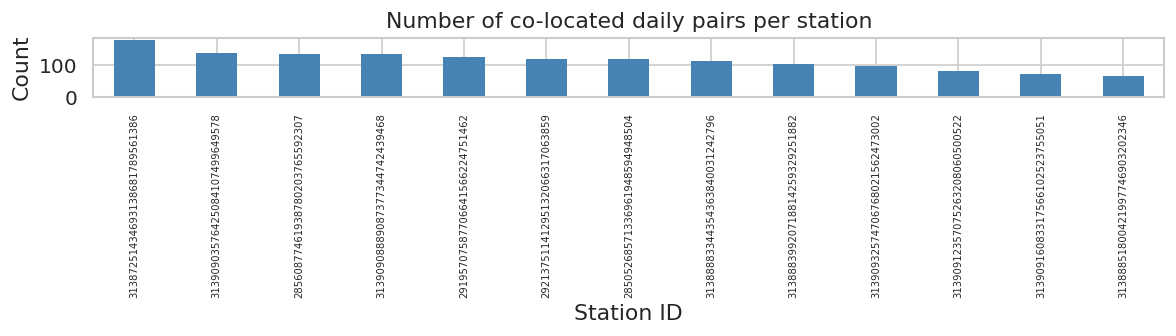

In [7]:
print('=== Basic statistics ===')
modis_cols = [f'AOD_MODIS_{band.split("_")[-1]}' for band in MODIS_BANDS]
display(all_df[modis_cols + ['AOD_Himawari']].describe().T.round(4))

# Per-station pair count
pair_counts = all_df.groupby('station_id').size().rename('n_pairs').sort_values(ascending=False)
print(f'\nMedian pairs per station: {pair_counts.median():.0f}')
print(f'Stations with ≥30 pairs : {(pair_counts >= 30).sum()}')

fig, ax = plt.subplots(figsize=(10, 3))
pair_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Number of co-located daily pairs per station')
ax.set_xlabel('Station ID'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
plt.tight_layout(); plt.show()

## 5 · AOD Value Distributions

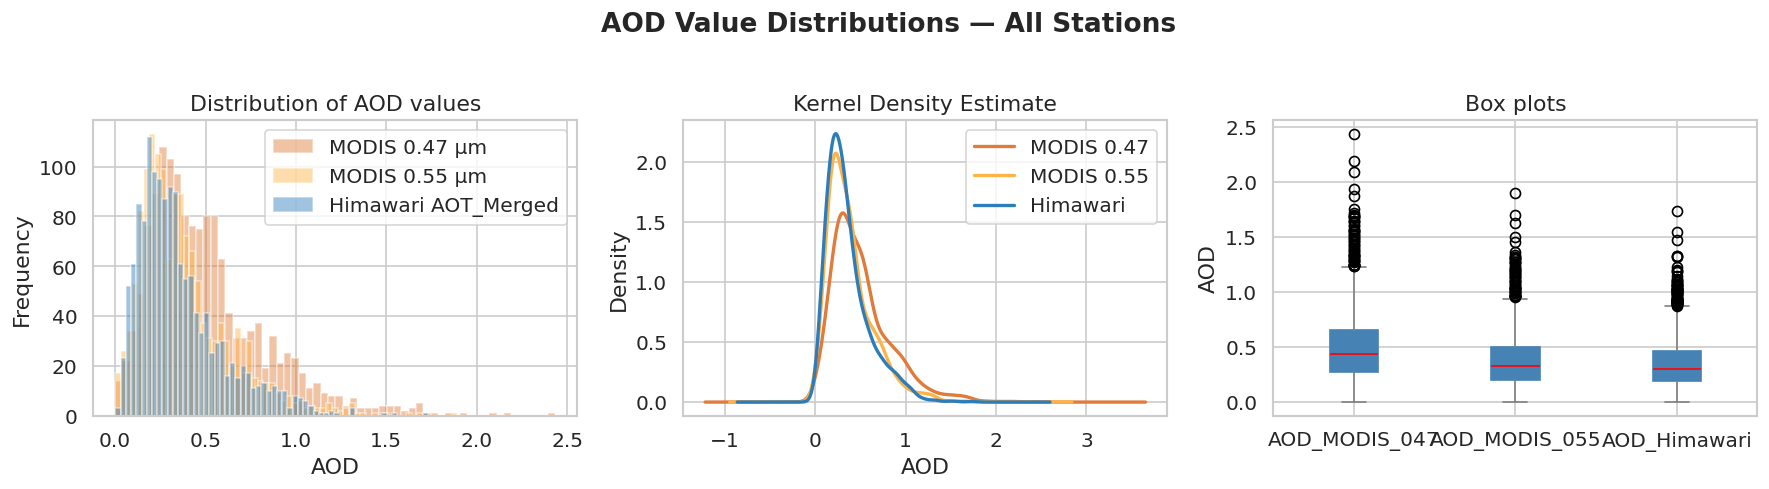

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modis_cols = [f'AOD_MODIS_{band.split("_")[-1]}' for band in MODIS_BANDS]

# Histograms
for col, color, label in [
    (modis_cols[0], '#E07B39', 'MODIS 0.47 µm'),
    (modis_cols[1], '#FFB347', 'MODIS 0.55 µm'),
    ('AOD_Himawari', '#2D7DBB', 'Himawari AOT_Merged')
]:
    all_df[col].plot.hist(bins=60, alpha=0.45, color=color, label=label, ax=axes[0])
axes[0].set_xlabel('AOD'); axes[0].set_title('Distribution of AOD values')
axes[0].legend()

# KDE
for col, color, label in [(modis_cols[0], '#E07B39', 'MODIS 0.47'),
                           (modis_cols[1], '#FFB347', 'MODIS 0.55'),
                           ('AOD_Himawari', '#2D7DBB', 'Himawari')]:
    all_df[col].plot.kde(ax=axes[1], color=color, lw=2)
axes[1].set_xlabel('AOD'); axes[1].set_title('Kernel Density Estimate')
axes[1].legend([l for _, _, l in [(modis_cols[0], '#E07B39', 'MODIS 0.47'),
                                   (modis_cols[1], '#FFB347', 'MODIS 0.55'),
                                   ('AOD_Himawari', '#2D7DBB', 'Himawari')]])

# Box plots
all_df[[modis_cols[0], modis_cols[1], 'AOD_Himawari']].plot.box(
    ax=axes[2],
    color={'boxes': 'steelblue', 'medians': 'red', 'whiskers': 'gray', 'caps': 'gray'},
    patch_artist=True
)
axes[2].set_title('Box plots'); axes[2].set_ylabel('AOD')

plt.suptitle('AOD Value Distributions — All Stations', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 6 · Global Correlation Analysis

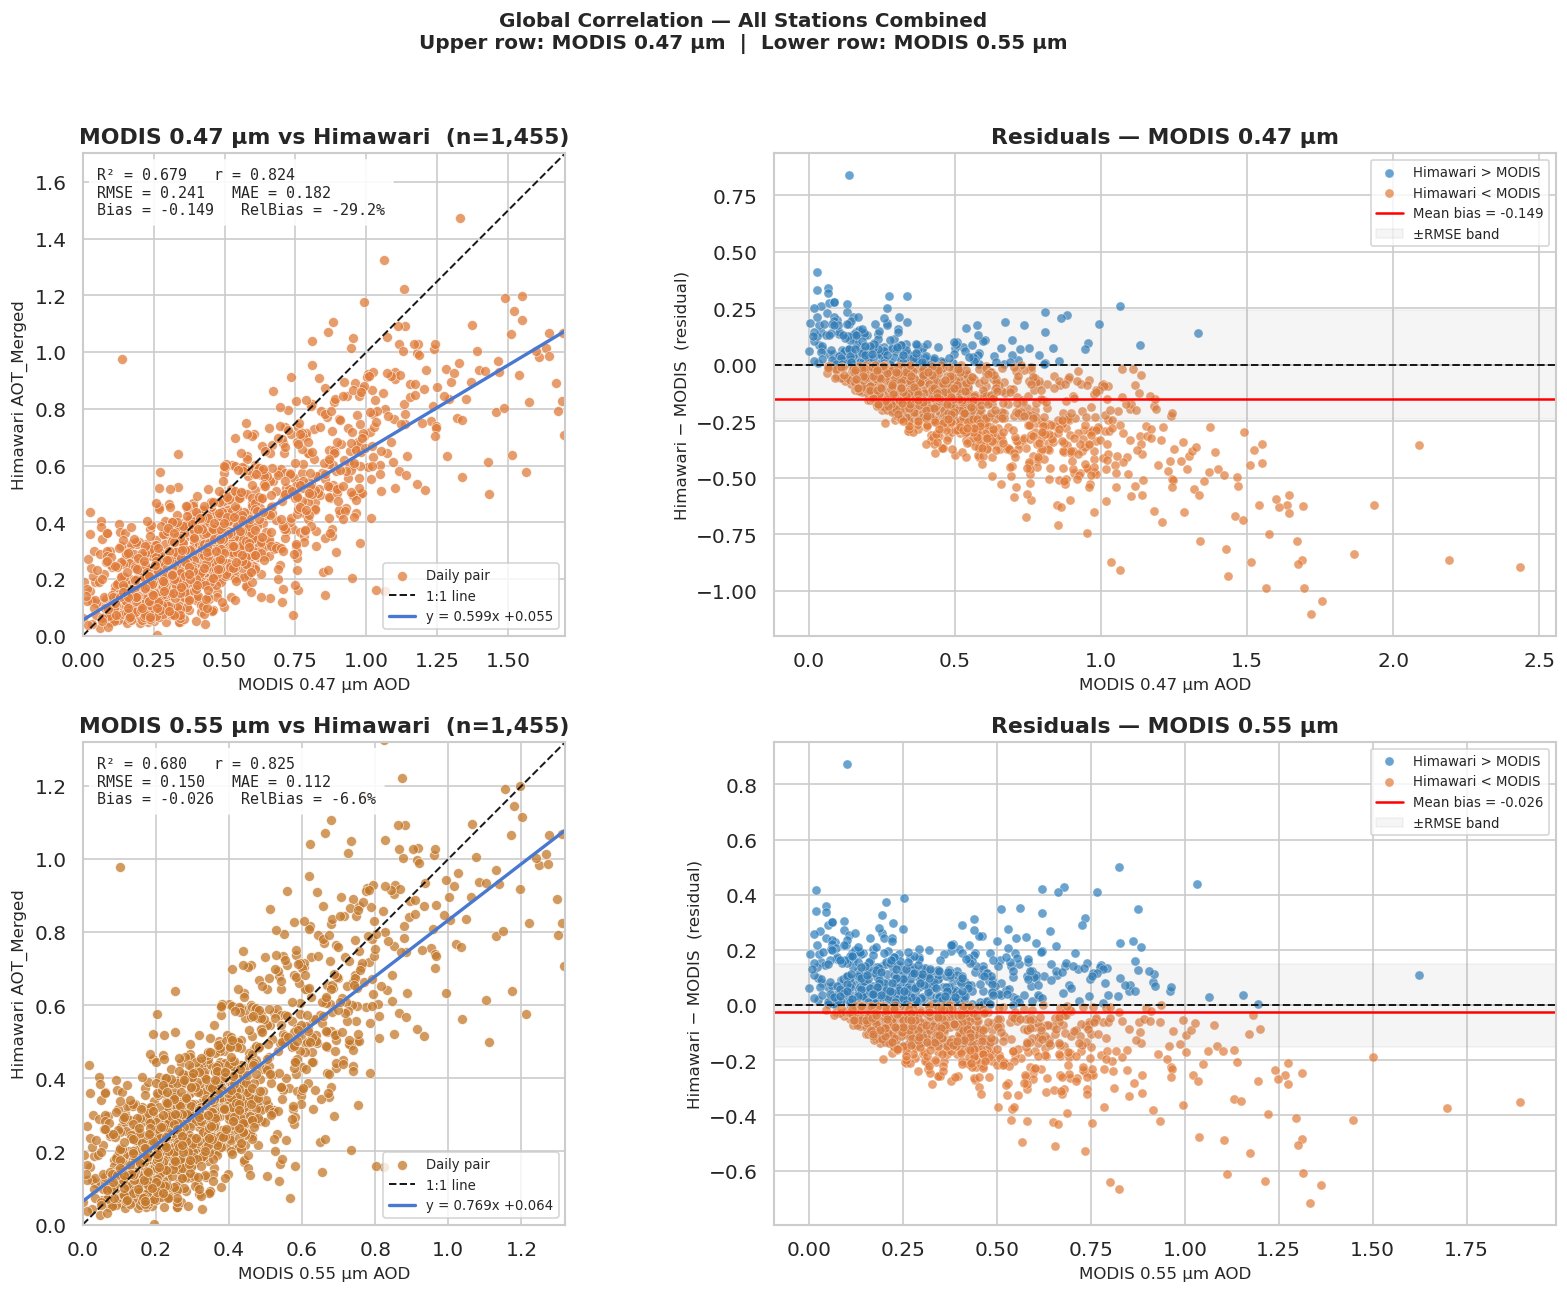

,n,r,R2,slope,intercept,RMSE,MAE,Bias,RelBias_pct
AOD_MODIS_047,1455.0,0.8238,0.6787,0.5992,0.0553,0.2413,0.1817,-0.1489,-29.2223
AOD_MODIS_055,1455.0,0.8247,0.6802,0.7693,0.0635,0.1504,0.1118,-0.0256,-6.6266


In [9]:
def regression_stats(x: pd.Series, y: pd.Series) -> dict:
    """Compute key regression / agreement statistics."""
    mask = x.notna() & y.notna()
    x, y = x[mask].values, y[mask].values
    if len(x) < 3:
        return dict(n=len(x), r=np.nan, R2=np.nan, slope=np.nan,
                    intercept=np.nan, RMSE=np.nan, MAE=np.nan,
                    Bias=np.nan, RelBias_pct=np.nan)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    rmse  = np.sqrt(mean_squared_error(x, y))
    mae   = mean_absolute_error(x, y)
    bias  = np.mean(y - x)           # Himawari − MODIS
    relbias = bias / np.mean(x) * 100
    return dict(n=len(x), r=r, R2=r**2, slope=slope, intercept=intercept,
                RMSE=rmse, MAE=mae, Bias=bias, RelBias_pct=relbias)

plot_pairs = [
    ('AOD_MODIS_047', 'MODIS 0.47 µm', '#E07B39'),
    ('AOD_MODIS_055', 'MODIS 0.55 µm', '#C4782A'),
]

# ── 2×2: left col = scatter+regression, right col = residuals ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=False, sharey=False)

gs_dict = {}   # store global stats for both bands

for i, (modis_col, band_label, color) in enumerate(plot_pairs):
    gs = regression_stats(all_df[modis_col], all_df['AOD_Himawari'])
    gs_dict[modis_col] = gs

    # ── Scatter ─────────────────────────────────────────────────────────────
    ax = axes[i, 0]
    valid = all_df[[modis_col, 'AOD_Himawari']].dropna()
    ax.scatter(valid[modis_col], valid['AOD_Himawari'],
               c=color, edgecolors='white', linewidths=0.4, s=35, alpha=0.75,
               label='Daily pair')

    q99 = max(valid[modis_col].quantile(0.99), valid['AOD_Himawari'].quantile(0.99))
    lims = [0, q99 * 1.05]
    ax.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    xfit = np.linspace(*lims, 200)
    ax.plot(xfit, gs['slope']*xfit + gs['intercept'], 'b-', lw=2,
            label=f"y = {gs['slope']:.3f}x {gs['intercept']:+.3f}")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f'{band_label} AOD', fontsize=10)
    ax.set_ylabel('Himawari AOT_Merged', fontsize=10)
    ax.set_title(f'{band_label} vs Himawari  (n={gs["n"]:,})', fontweight='bold')
    stats_text = (f"R² = {gs['R2']:.3f}   r = {gs['r']:.3f}\n"
                  f"RMSE = {gs['RMSE']:.3f}   MAE = {gs['MAE']:.3f}\n"
                  f"Bias = {gs['Bias']:+.3f}   RelBias = {gs['RelBias_pct']:+.1f}%")
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
            va='top', ha='left', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))
    ax.legend(fontsize=8, loc='lower right')

    # ── Residuals ────────────────────────────────────────────────────────────
    ax2 = axes[i, 1]
    resid = all_df['AOD_Himawari'] - all_df[modis_col]
    valid_resid = all_df[[modis_col]].dropna().join(resid.rename('resid')).dropna()

    # colour by sign so over/under-estimation is immediately visible
    pos = valid_resid['resid'] >= 0
    ax2.scatter(valid_resid.loc[pos, modis_col], valid_resid.loc[pos, 'resid'],
                c='#2D7DBB', s=30, alpha=0.7, edgecolors='white', lw=0.3,
                label='Himawari > MODIS')
    ax2.scatter(valid_resid.loc[~pos, modis_col], valid_resid.loc[~pos, 'resid'],
                c='#E07B39', s=30, alpha=0.7, edgecolors='white', lw=0.3,
                label='Himawari < MODIS')
    ax2.axhline(0,          color='k',   lw=1.2, linestyle='--')
    ax2.axhline(gs['Bias'], color='red', lw=1.5, linestyle='-',
                label=f"Mean bias = {gs['Bias']:+.3f}")
    # ±RMSE band
    ax2.axhspan(-gs['RMSE'], gs['RMSE'], color='gray', alpha=0.08, label=f'±RMSE band')
    ax2.set_xlabel(f'{band_label} AOD', fontsize=10)
    ax2.set_ylabel('Himawari − MODIS  (residual)', fontsize=10)
    ax2.set_title(f'Residuals — {band_label}', fontweight='bold')
    ax2.legend(fontsize=8)

plt.suptitle('Global Correlation — All Stations Combined\n'
             'Upper row: MODIS 0.47 µm  |  Lower row: MODIS 0.55 µm',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Summary table for both bands
pd.DataFrame(gs_dict).T.round(4)


## 7 · Per-Station Correlation Statistics

In [10]:
station_stats = []
for sid, df in station_dfs.items():
    if len(df) < 5:
        continue

    for band in MODIS_BANDS:
        col_name = f'AOD_MODIS_{band.split("_")[-1]}'
        s = regression_stats(df[col_name], df['AOD_Himawari'])
        s['station_id'] = sid
        s['band'] = band
        if 'Name' in df.columns:
            s['Name'] = df['Name'].iloc[0]
        station_stats.append(s)

stats_df = pd.DataFrame(station_stats).set_index(['station_id', 'band']).round(4)

print(f'Stations with ≥5 pairs: {stats_df.shape[0]}')
display(stats_df.sort_values(['band','R2'], ascending=[True, False]).head(40))

Stations with ≥5 pairs: 26


,,n,r,R2,slope,intercept,RMSE,MAE,Bias,RelBias_pct,Name
station_id,band,,,,,,,,,,
29213751141295132066317063859,Optical_Depth_047,117,0.8746,0.7650,0.4437,0.0913,0.2536,0.1720,-0.1618,-35.5551,Quảng Bình: Khu kinh tế Hòn La (KK)
31390908889087377344742439468,Optical_Depth_047,132,0.8735,0.7629,0.6687,0.0023,0.2630,0.2109,-0.2001,-32.7610,Hà Nội: Công viên Nhân Chính - Khuất Duy Tiến ...
31390903576425084107499649578,Optical_Depth_047,135,0.8652,0.7486,0.6975,-0.0251,0.2715,0.2228,-0.2157,-34.2218,Hà Nội: ĐHBK cổng Parabol đường Giải Phóng (KK)
28505268571336961948594948504,Optical_Depth_047,117,0.8636,0.7458,0.6468,0.0169,0.2833,0.2292,-0.2156,-32.7605,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK)
29195707587706641566224751462,Optical_Depth_047,124,0.8621,0.7432,0.7125,0.0005,0.2308,0.1630,-0.1459,-28.6406,Thái nguyên: Đường Hùng Vương - Tp Thái Nguyên...
28560877461938780203765592307,Optical_Depth_047,134,0.8607,0.7409,0.7016,0.0058,0.2320,0.1794,-0.1638,-28.8270,Hà Nội: 556 Nguyễn Văn Cừ (KK)
31388851800421997746903202346,Optical_Depth_047,63,0.8294,0.6879,0.5687,0.0776,0.3070,0.2453,-0.2156,-31.7087,Đà Nẵng: Khuôn viên trường ĐH sư phạm Đà Nẵng ...
31388883344354363840031242796,Optical_Depth_047,111,0.8066,0.6506,0.6416,0.0525,0.2821,0.2095,-0.1665,-27.2461,Hà Nam: Công Viên Nam Cao - P.Quang Trung - TP...
31387251434693138681789561386,Optical_Depth_047,176,0.7848,0.6158,0.5780,0.0514,0.2352,0.1637,-0.1396,-30.8419,Bắc Giang: Khu liên cơ quan tỉnh Bắc Giang - P...


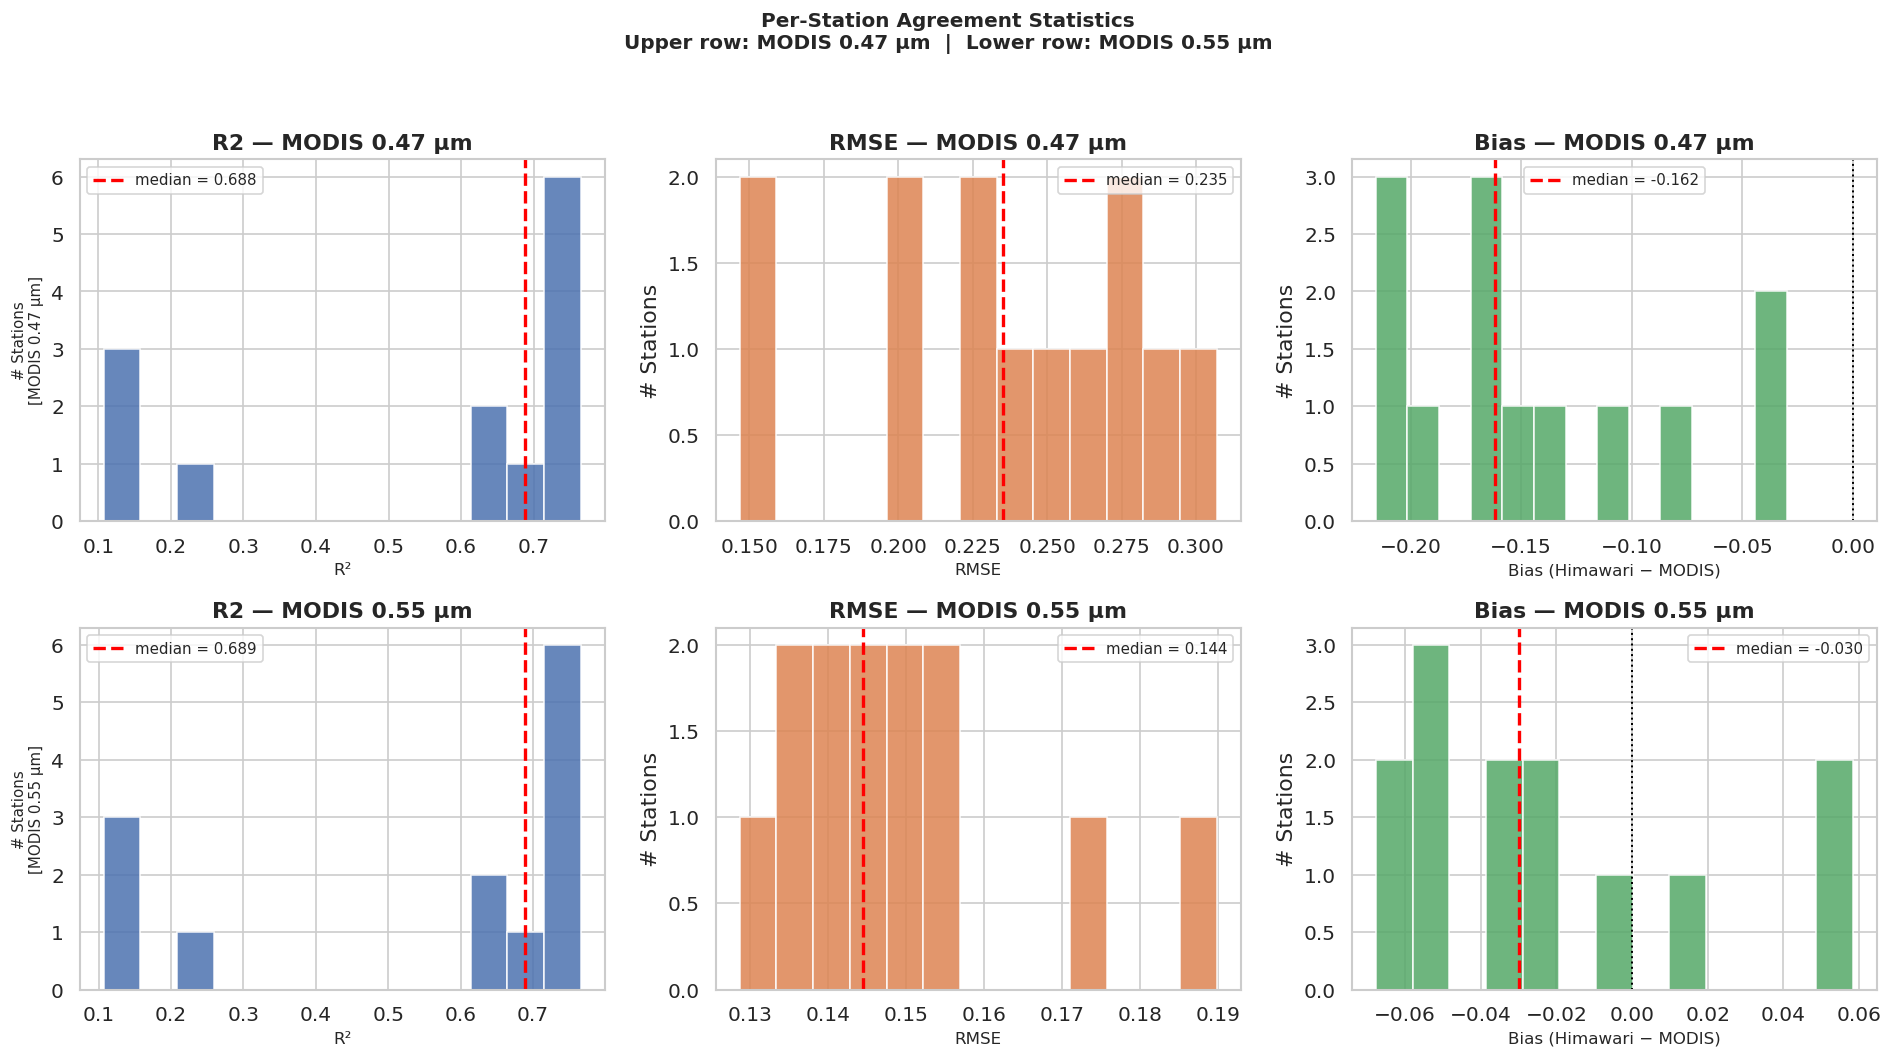

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

band_configs = [
    ('Optical_Depth_047', '0.47 µm', '#E07B39'),
    ('Optical_Depth_055', '0.55 µm', '#C4782A'),
]

for row, (band, band_label, base_color) in enumerate(band_configs):
    band_stats = stats_df.xs(band, level='band')

    for col_idx, (metric, color, xlabel) in enumerate([
        ('R2',   '#4C72B0', 'R²'),
        ('RMSE', '#DD8452', 'RMSE'),
        ('Bias', '#55A868', 'Bias (Himawari − MODIS)'),
    ]):
        ax = axes[row, col_idx]
        data = band_stats[metric].dropna()
        ax.hist(data, bins=min(15, len(data)), color=color, edgecolor='white', alpha=0.85)
        median_val = data.median()
        ax.axvline(median_val, color='red', lw=2, linestyle='--',
                   label=f'median = {median_val:.3f}')
        if metric == 'Bias':
            ax.axvline(0, color='black', lw=1.2, linestyle=':')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel('# Stations')
        ax.set_title(f'{metric} — MODIS {band_label}', fontweight='bold')
        ax.legend(fontsize=9)

# Row labels
for row, (_, band_label, _) in enumerate(band_configs):
    axes[row, 0].set_ylabel(f'# Stations\n[MODIS {band_label}]', fontsize=9)

plt.suptitle('Per-Station Agreement Statistics\n'
             'Upper row: MODIS 0.47 µm  |  Lower row: MODIS 0.55 µm',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 8 · Seasonal / Monthly Correlation

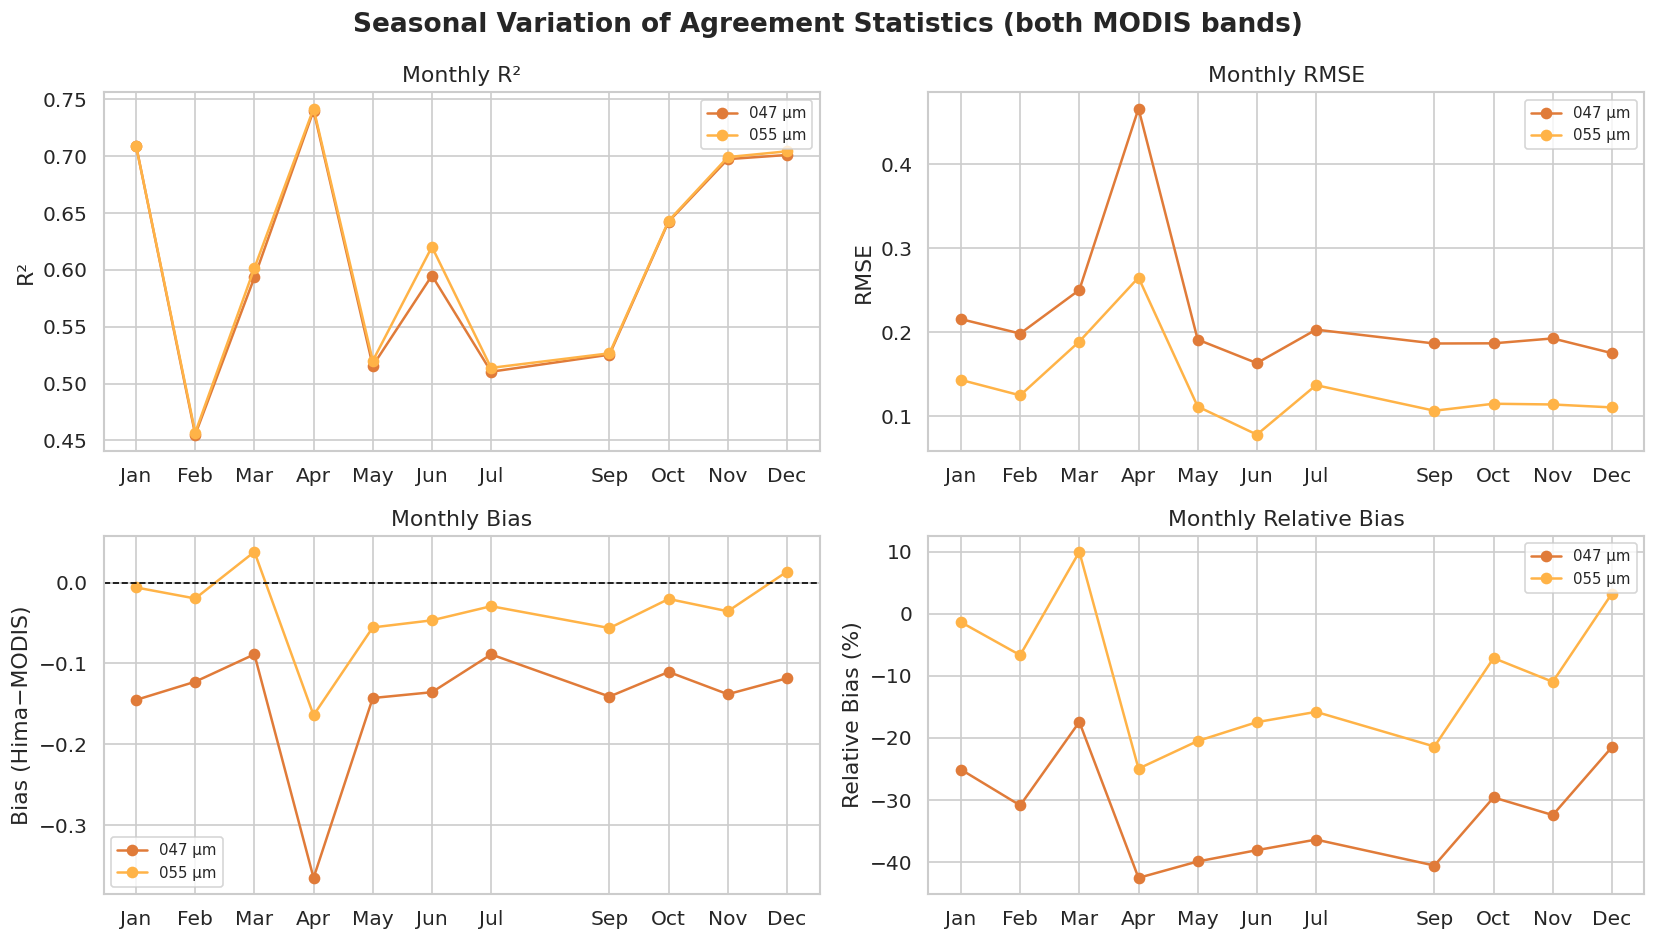

In [12]:
all_df['month'] = all_df['datetime'].dt.month
all_df['year']  = all_df['datetime'].dt.year

monthly_dfs = {}
for band in MODIS_BANDS:
    modis_col = f'AOD_MODIS_{band.split("_")[-1]}'
    monthly_stats = []
    for m, grp in all_df.groupby('month'):
        if len(grp) < 10:
            continue
        s = regression_stats(grp[modis_col], grp['AOD_Himawari'])
        s['month'] = m
        monthly_stats.append(s)
    monthly_dfs[band] = pd.DataFrame(monthly_stats).set_index('month')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, ylabel, title in [
    (axes[0,0], 'R2',           'R²',                'Monthly R²'),
    (axes[0,1], 'RMSE',         'RMSE',              'Monthly RMSE'),
    (axes[1,0], 'Bias',         'Bias (Hima−MODIS)', 'Monthly Bias'),
    (axes[1,1], 'RelBias_pct',  'Relative Bias (%)', 'Monthly Relative Bias'),
]:
    for band, style in [(MODIS_BANDS[0], '#E07B39'), (MODIS_BANDS[1], '#FFB347')]:
        df = monthly_dfs[band]
        ax.plot(df.index, df[col], marker='o', color=style, label=f"{band.split('_')[-1]} µm")
    ax.set_xticks(monthly_dfs[MODIS_BANDS[0]].index)
    ax.set_xticklabels([month_names[m-1] for m in monthly_dfs[MODIS_BANDS[0]].index])
    ax.set_title(title); ax.set_ylabel(ylabel)
    if col == 'Bias':
        ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.legend(fontsize=9)

plt.suptitle('Seasonal Variation of Agreement Statistics (both MODIS bands)', fontweight='bold')
plt.tight_layout(); plt.show()

## 9 · Time-Series Comparison — Top-N Stations

In [13]:
stats_df

n       r      R2   slope  \
station_id                    band                                             
28505268571336961948594948504 Optical_Depth_047  117  0.8636  0.7458  0.6468   
                              Optical_Depth_055  117  0.8640  0.7465  0.8302   
28560877461938780203765592307 Optical_Depth_047  134  0.8607  0.7409  0.7016   
                              Optical_Depth_055  134  0.8606  0.7406  0.9006   
29195707587706641566224751462 Optical_Depth_047  124  0.8621  0.7432  0.7125   
                              Optical_Depth_055  124  0.8619  0.7429  0.9156   
29213751141295132066317063859 Optical_Depth_047  117  0.8746  0.7650  0.4437   
                              Optical_Depth_055  117  0.8752  0.7659  0.5698   
31387251434693138681789561386 Optical_Depth_047  176  0.7848  0.6158  0.5780   
                              Optical_Depth_055  176  0.7836  0.6140  0.7436   
31388839920718814259329251882 Optical_Depth_047  102  0.5082  0.2582  0.3476   
                              Optical_Depth_055  102  0.5086  0.2586  0.4742   
31388851800421997746903202346 Optical_Depth_047   63  0.8294  0.6879  0.5687   
                              Optical_Depth_055   63  0.8303  0.6894  0.7311   
31388883344354363840031242796 Optical_Depth_047  111  0.8066  0.6506  0.6416   
                              Optical_Depth_055  111  0.8071  0.6515  0.8227   
31390903576425084107499649578 Optical_Depth_047  135  0.8652  0.7486  0.6975   
                              Optical_Depth_055  135  0.8652  0.7486  0.8937   
31390908889087377344742439468 Optical_Depth_047  132  0.8735  0.7629  0.6687   
                              Optical_Depth_055  132  0.8739  0.7637  0.8578   
31390912357075263208060500522 Optical_Depth_047   79  0.3379  0.1142  0.1844   
                              Optical_Depth_055   79  0.3391  0.1150  0.2521   
31390916083317566102523755051 Optical_Depth_047   70  0.3873  0.1500  0.2312   
                              Optical_Depth_055   70  0.3889  0.1512  0.3161   
31390932574706768021562473002 Optical_Depth_047   95  0.3274  0.1072  0.2726   
                              Optical_Depth_055   95  0.3268  0.1068  0.3727   

                                                 intercept    RMSE     MAE  \
station_id                    band                                           
28505268571336961948594948504 Optical_Depth_047     0.0169  0.2833  0.2292   
                              Optical_Depth_055     0.0241  0.1548  0.1207   
28560877461938780203765592307 Optical_Depth_047     0.0058  0.2320  0.1794   
                              Optical_Depth_055     0.0133  0.1390  0.1039   
29195707587706641566224751462 Optical_Depth_047     0.0005  0.2308  0.1630   
                              Optical_Depth_055     0.0076  0.1514  0.1072   
29213751141295132066317063859 Optical_Depth_047     0.0913  0.2536  0.1720   
                              Optical_Depth_055     0.0956  0.1438  0.0966   
31387251434693138681789561386 Optical_Depth_047     0.0514  0.2352  0.1637   
                              Optical_Depth_055     0.0566  0.1552  0.1125   
31388839920718814259329251882 Optical_Depth_047     0.1822  0.1468  0.1134   
                              Optical_Depth_055     0.1834  0.1287  0.1066   
31388851800421997746903202346 Optical_Depth_047     0.0776  0.3070  0.2453   
                              Optical_Depth_055     0.0853  0.1738  0.1360   
31388883344354363840031242796 Optical_Depth_047     0.0525  0.2821  0.2095   
                              Optical_Depth_055     0.0599  0.1899  0.1318   
31390903576425084107499649578 Optical_Depth_047    -0.0251  0.2715  0.2228   
                              Optical_Depth_055    -0.0164  0.1508  0.1108   
31390908889087377344742439468 Optical_Depth_047     0.0023  0.2630  0.2109   
                              Optical_Depth_055     0.0098  0.1445  0.1113   
31390912357075263208060500522 Optical_Depth_047     0.2137  0.1988  0.1645   
                

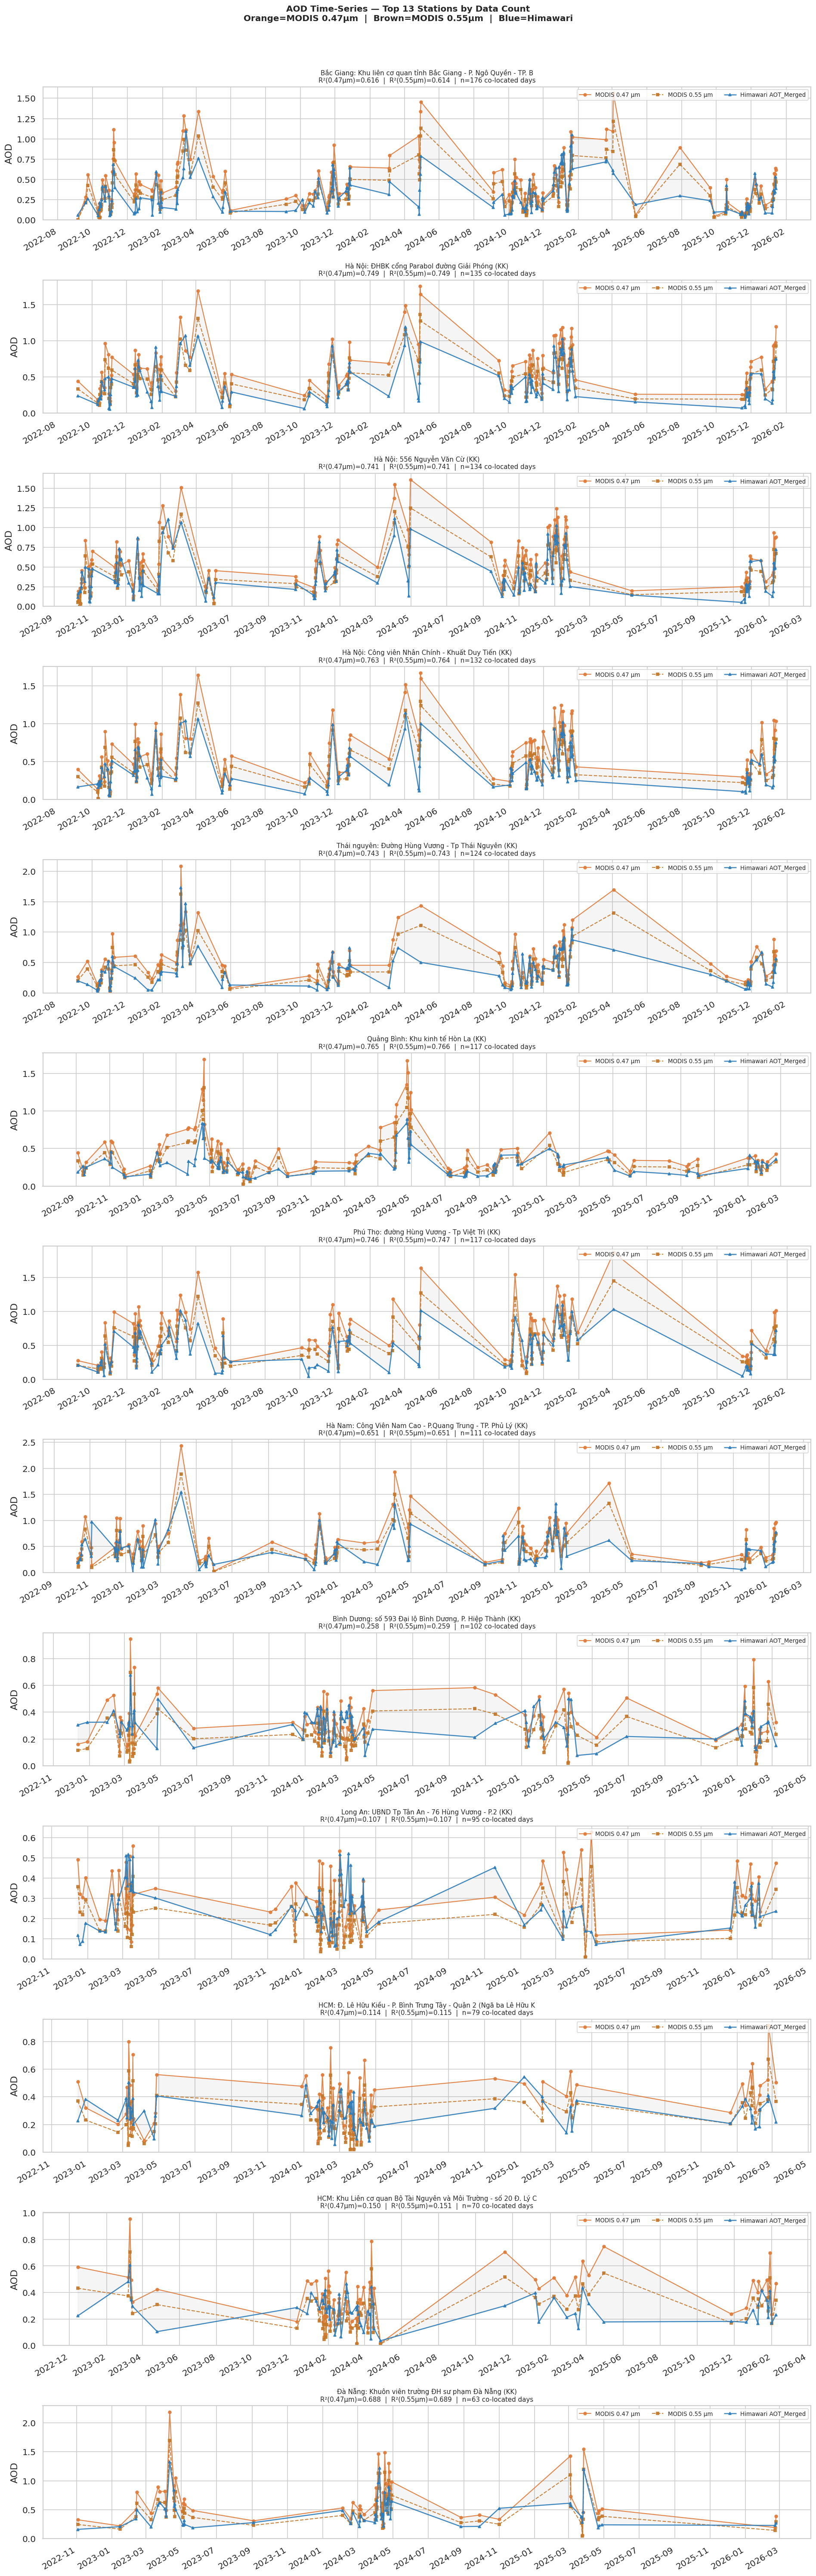

In [14]:
TOP_N = 13   # adjust as needed

# stats_df has MultiIndex (station_id, band); get unique stations by max n
n_by_station = all_df.groupby('station_id').size().sort_values(ascending=False)
top_stations = n_by_station.head(TOP_N).index.tolist()

fig, axes = plt.subplots(TOP_N, 1, figsize=(16, 3.8 * TOP_N), sharex=False)
if TOP_N == 1:
    axes = [axes]

for ax, sid in zip(axes, top_stations):
    df = station_dfs[sid]
    name = df['Name'].iloc[0] if 'Name' in df.columns else sid

    # ── Plot all three series on the same axes ─────────────────────────────
    ax.plot(df.index, df['AOD_MODIS_047'], 'o-', color='#E07B39', ms=4, lw=1.3,
            label='MODIS 0.47 µm', alpha=0.9)
    ax.plot(df.index, df['AOD_MODIS_055'], 's-', color='#C4782A', ms=4, lw=1.3,
            label='MODIS 0.55 µm', alpha=0.9, linestyle='--')
    ax.plot(df.index, df['AOD_Himawari'],  '^-', color='#2D7DBB', ms=4, lw=1.5,
            label='Himawari AOT_Merged', alpha=0.9)

    # Shade gap between 047 and Himawari to make bias visible
    ax.fill_between(df.index, df['AOD_MODIS_047'], df['AOD_Himawari'],
                    alpha=0.08, color='gray')

    # Per-band R² from stats_df
    def _r2(sid, band):
        key = (sid, band)
        return f"{stats_df.loc[key, 'R2']:.3f}" if key in stats_df.index else 'N/A'

    r2_047 = _r2(sid, 'Optical_Depth_047')
    r2_055 = _r2(sid, 'Optical_Depth_055')
    n = df[['AOD_MODIS_047', 'AOD_Himawari']].dropna().shape[0]

    ax.set_title(
        f"{str(name)[:65]}\n"
        f"R²(0.47µm)={r2_047}  |  R²(0.55µm)={r2_055}  |  n={n} co-located days",
        fontsize=9
    )
    ax.set_ylabel('AOD')
    ax.legend(fontsize=8, loc='upper right', ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylim(bottom=0)

plt.suptitle(f'AOD Time-Series — Top {TOP_N} Stations by Data Count\n'
             'Orange=MODIS 0.47µm  |  Brown=MODIS 0.55µm  |  Blue=Himawari',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 10 · Interative Station Selector

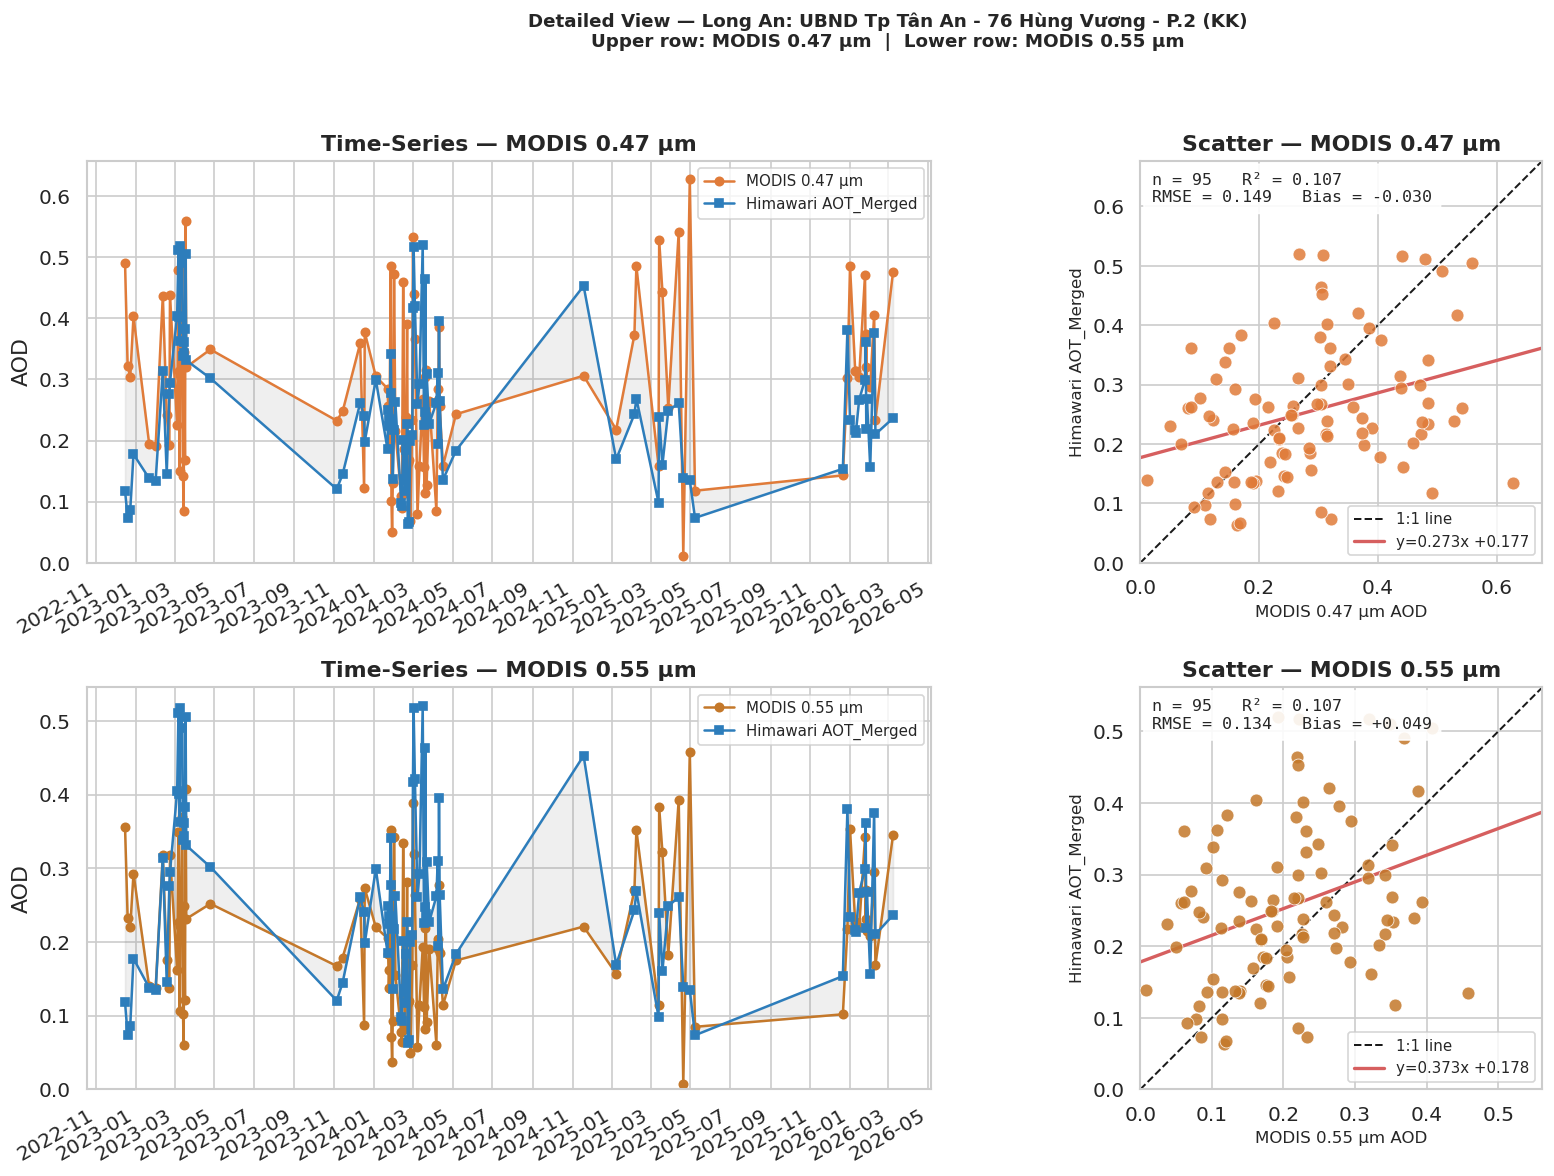

In [18]:
# Change STATION_ID to inspect any station in detail
STATION_ID = '31390932574706768021562473002'   # ← replace with any station ID string

df  = station_dfs[STATION_ID]
name = df['Name'].iloc[0] if 'Name' in df.columns else STATION_ID

band_configs = [
    ('AOD_MODIS_047', 'MODIS 0.47 µm', '#E07B39', 'Optical_Depth_047'),
    ('AOD_MODIS_055', 'MODIS 0.55 µm', '#C4782A', 'Optical_Depth_055'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row, (modis_col, band_label, color, band_key) in enumerate(band_configs):
    s = regression_stats(df[modis_col], df['AOD_Himawari'])

    # ── Time-series ─────────────────────────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(df.index, df[modis_col],    'o-', color=color,    ms=5, lw=1.5, label=band_label)
    ax.plot(df.index, df['AOD_Himawari'], 's-', color='#2D7DBB', ms=5, lw=1.5,
            label='Himawari AOT_Merged')
    ax.fill_between(df.index, df[modis_col], df['AOD_Himawari'],
                    alpha=0.12, color='gray', label='_gap')
    ax.set_title(f'Time-Series — {band_label}', fontweight='bold')
    ax.set_ylabel('AOD')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylim(bottom=0)

    # ── Scatter ─────────────────────────────────────────────────────────────
    ax2 = axes[row, 1]
    valid = df[[modis_col, 'AOD_Himawari']].dropna()
    ax2.scatter(valid[modis_col], valid['AOD_Himawari'],
                c=color, edgecolors='white', linewidths=0.5, s=60, alpha=0.85,
                zorder=3)
    lim_max = max(valid[modis_col].max(), valid['AOD_Himawari'].max()) * 1.08
    lims = [0, lim_max]
    ax2.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    xfit = np.linspace(*lims, 200)
    ax2.plot(xfit, s['slope']*xfit + s['intercept'], 'r-', lw=2,
             label=f"y={s['slope']:.3f}x {s['intercept']:+.3f}")
    ax2.set_xlim(lims); ax2.set_ylim(lims)
    ax2.set_aspect('equal', adjustable='box')
    ax2.set_xlabel(f'{band_label} AOD', fontsize=10)
    ax2.set_ylabel('Himawari AOT_Merged', fontsize=10)
    ax2.set_title(f'Scatter — {band_label}', fontweight='bold')
    stats_text = (f"n = {s['n']}   R² = {s['R2']:.3f}\n"
                  f"RMSE = {s['RMSE']:.3f}   Bias = {s['Bias']:+.3f}")
    ax2.text(0.03, 0.97, stats_text, transform=ax2.transAxes,
             va='top', fontsize=10, fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))
    ax2.legend(fontsize=9, loc='lower right')

plt.suptitle(
    f'Detailed View — {str(name)[:70]}\n'
    f'Upper row: MODIS 0.47 µm  |  Lower row: MODIS 0.55 µm',
    fontweight='bold', fontsize=11
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 11 · Global Time-Series (Monthly Mean, All Stations)

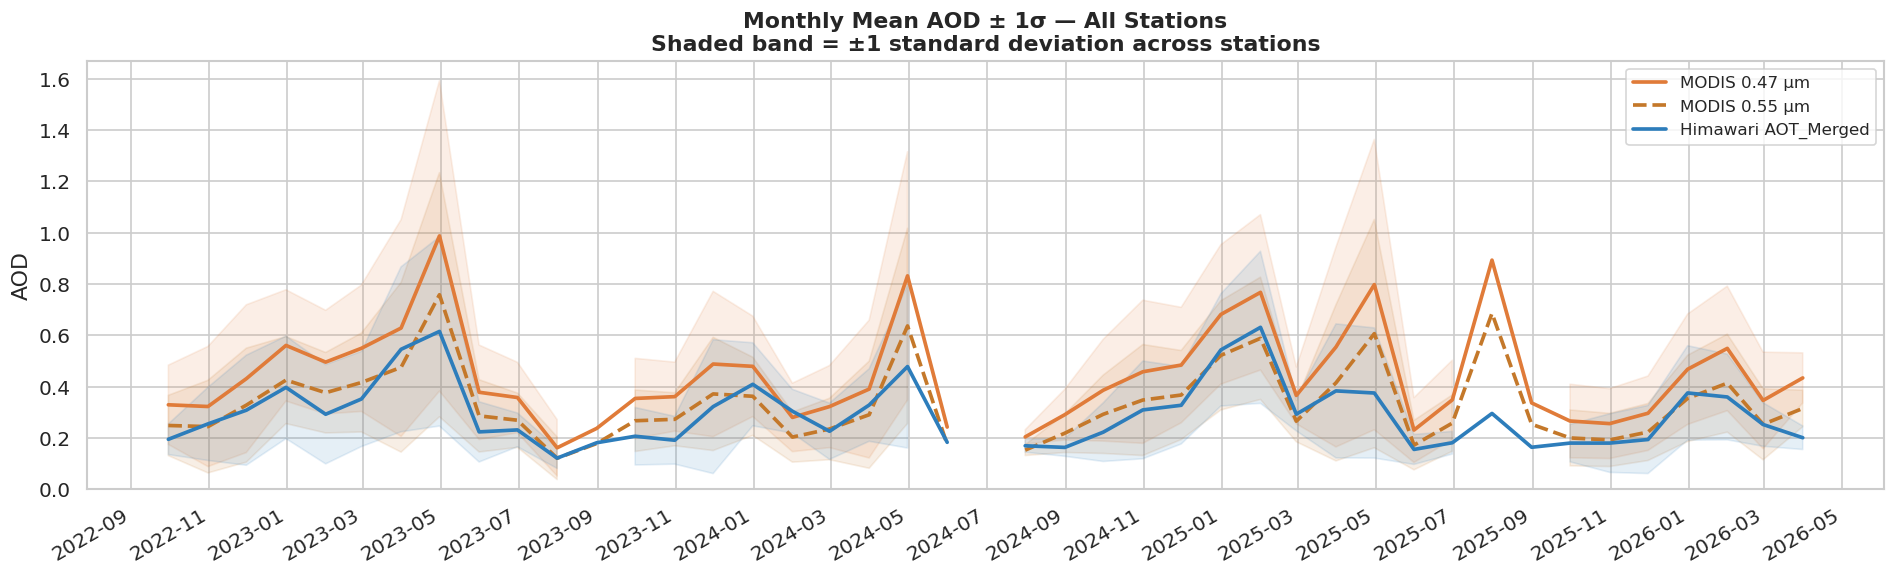

In [ ]:
cols_to_plot = ['AOD_MODIS_047', 'AOD_MODIS_055', 'AOD_Himawari']

monthly_mean = (
    all_df.set_index('datetime')[cols_to_plot]
    .resample('1ME')
    .agg(['mean', 'std'])
)
monthly_mean.columns = ['_'.join(c) for c in monthly_mean.columns]

fig, ax = plt.subplots(figsize=(16, 5))

series_cfg = [
    ('AOD_MODIS_047', '#E07B39', 'MODIS 0.47 µm',  '-'),
    ('AOD_MODIS_055', '#C4782A', 'MODIS 0.55 µm',  '--'),
    ('AOD_Himawari',  '#2D7DBB', 'Himawari AOT_Merged', '-'),
]

for col, color, label, ls in series_cfg:
    mu  = monthly_mean[f'{col}_mean']
    sig = monthly_mean[f'{col}_std']
    ax.plot(mu.index, mu, color=color, lw=2.2, linestyle=ls, label=label, zorder=3)
    ax.fill_between(mu.index, (mu - sig).clip(lower=0), mu + sig,
                    color=color, alpha=0.12)

ax.set_title('Monthly Mean AOD ± 1σ — All Stations\n'
             'Shaded band = ±1 standard deviation across stations',
             fontweight='bold')
ax.set_ylabel('AOD')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


## 12 · Heatmap — R² by Station × Month

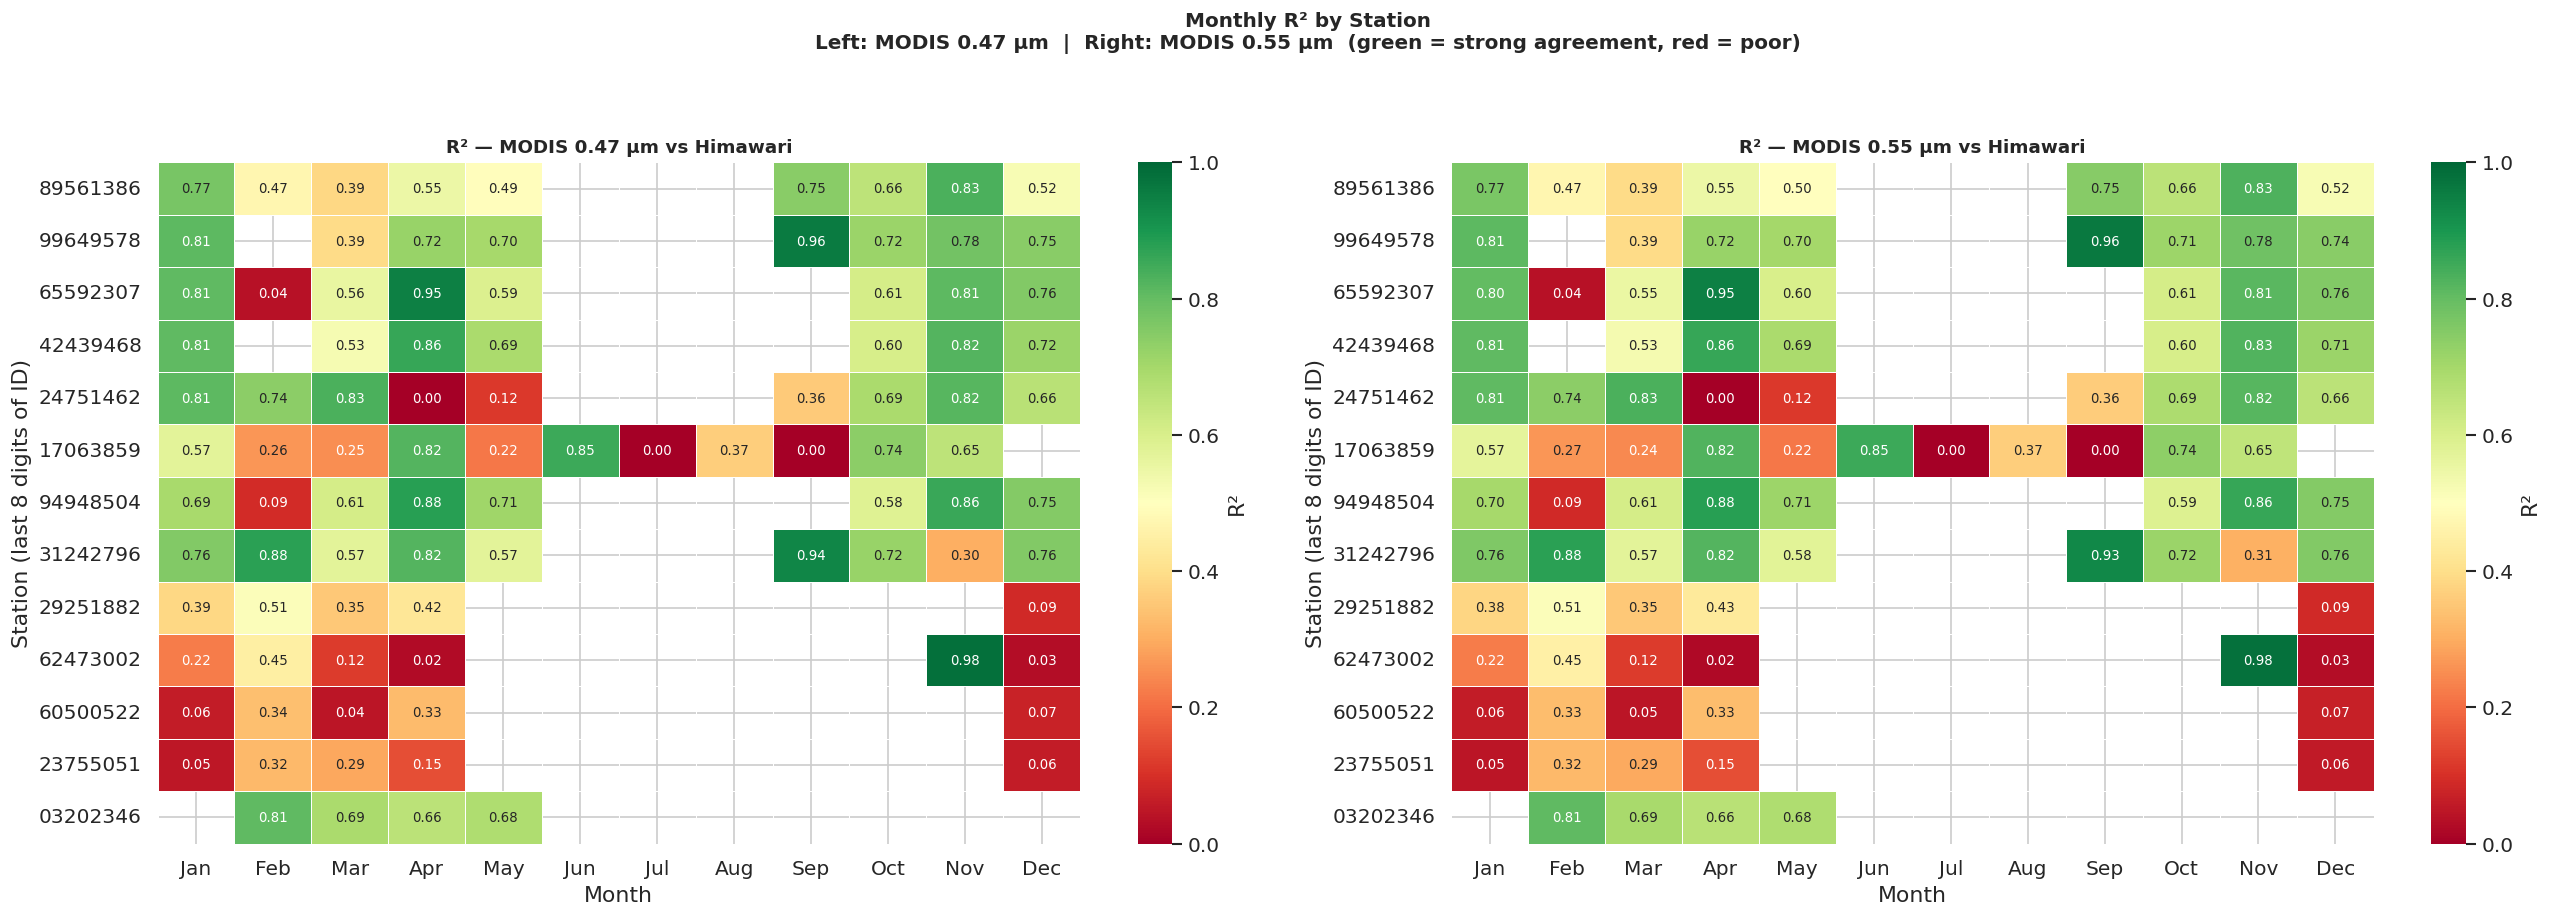

In [ ]:
MIN_MONTHLY_N = 3

# Use station IDs with n >= 10 in at least one band
station_n = stats_df.groupby(level='station_id')['n'].max()
HEATMAP_STATIONS = station_n[station_n >= 10].sort_values(ascending=False).head(15).index.tolist()

band_pairs = [
    ('Optical_Depth_047', 'AOD_MODIS_047', 'MODIS 0.47 µm'),
    ('Optical_Depth_055', 'AOD_MODIS_055', 'MODIS 0.55 µm'),
]

fig, axes = plt.subplots(1, 2, figsize=(22, max(4, len(HEATMAP_STATIONS) * 0.6)))

for ax, (band_key, modis_col, band_label) in zip(axes, band_pairs):
    pivot_r2 = pd.DataFrame(index=HEATMAP_STATIONS, columns=range(1, 13), dtype=float)

    for sid in HEATMAP_STATIONS:
        df = station_dfs[sid].copy()
        df['month'] = df.index.month
        for m, grp in df.groupby('month'):
            valid = grp[[modis_col, 'AOD_Himawari']].dropna()
            if len(valid) >= MIN_MONTHLY_N:
                r, _ = stats.pearsonr(valid[modis_col], valid['AOD_Himawari'])
                pivot_r2.loc[sid, m] = round(r**2, 3)

    pivot_r2.columns = [month_names[m-1] for m in pivot_r2.columns]
    # Use last 8 digits of station ID as short label
    pivot_r2.index = [str(s)[-8:] for s in pivot_r2.index]

    sns.heatmap(
        pivot_r2.astype(float), annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.5, ax=ax, cbar_kws={'label': 'R²'},
        annot_kws={'size': 8}
    )
    ax.set_title(f'R² — {band_label} vs Himawari', fontweight='bold', fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel('Station (last 8 digits of ID)')

plt.suptitle('Monthly R² by Station\n'
             'Left: MODIS 0.47 µm  |  Right: MODIS 0.55 µm  '
             '(green = strong agreement, red = poor)',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 13 · Summary Table — Export

In [ ]:
export_path = 'AOD_station_correlation_summary.csv'
stats_df.sort_values(['band', 'R2'], ascending=[True, False]).to_csv(export_path)
print(f'Saved → {export_path}')

# Per-band global stats
gs_047 = regression_stats(all_df['AOD_MODIS_047'], all_df['AOD_Himawari'])
gs_055 = regression_stats(all_df['AOD_MODIS_055'], all_df['AOD_Himawari'])
stats_047 = stats_df.xs('Optical_Depth_047', level='band')
stats_055 = stats_df.xs('Optical_Depth_055', level='band')

summary = {
    'Metric': [
        'N co-located records', 'N stations',
        'Median R²  (0.47 µm)', 'Median R²  (0.55 µm)',
        'Median RMSE (0.47 µm)', 'Median RMSE (0.55 µm)',
        'Global Bias  (0.47 µm)  Hima−MODIS',
        'Global Bias  (0.55 µm)  Hima−MODIS',
        'Stations R²≥0.7  (0.47 µm)',
        'Stations R²≥0.7  (0.55 µm)',
    ],
    'Value': [
        f"{len(all_df):,}",
        f"{all_df['station_id'].nunique()}",
        f"{stats_047['R2'].median():.3f}",
        f"{stats_055['R2'].median():.3f}",
        f"{stats_047['RMSE'].median():.3f}",
        f"{stats_055['RMSE'].median():.3f}",
        f"{gs_047['Bias']:+.3f}  ({gs_047['RelBias_pct']:+.1f}%)",
        f"{gs_055['Bias']:+.3f}  ({gs_055['RelBias_pct']:+.1f}%)",
        f"{(stats_047['R2'] >= 0.7).sum()} / {len(stats_047)}",
        f"{(stats_055['R2'] >= 0.7).sum()} / {len(stats_055)}",
    ]
}
display(pd.DataFrame(summary).set_index('Metric'))


Saved → AOD_station_correlation_summary.csv


,Value
Metric,
N co-located records,"1,455"
N stations,13
Median R² (0.47 µm),0.688
Median R² (0.55 µm),0.689
Median RMSE (0.47 µm),0.235
Median RMSE (0.55 µm),0.144
Global Bias (0.47 µm) Hima−MODIS,-0.149 (-29.2%)
Global Bias (0.55 µm) Hima−MODIS,-0.026 (-6.6%)
Stations R²≥0.7 (0.47 µm),6 / 13
